# Daily Challenge: Classification with Neural Networks in TensorFlow

Week 10, Day 4

Goal: classify points from two concentric circles with a neural network, starting from a model that fails and improving it step by step (more layers, better optimizer, non-linear activation functions), while visualising the decision boundaries.

## 1. Understand Classification Types

**Binary classification**: each example belongs to exactly **one of two** classes. The model usually has one output neuron with a sigmoid activation that gives the probability of the positive class, trained with binary cross-entropy.
*Example:* deciding whether an email is **spam or not spam**, or whether a patient has a disease or not. The circles problem in this notebook is binary: inner circle (1) vs outer circle (0).

**Multi-class classification**: each example belongs to exactly **one class among three or more**. The model has one output neuron per class with a softmax activation, so the probabilities sum to 1, trained with categorical cross-entropy.
*Example:* recognising a handwritten digit (0–9) in MNIST, or classifying a photo as cat, dog or horse.

**Multi-label classification**: each example can belong to **several classes at the same time** (zero, one or many labels). The model has one output neuron per label, each with its own sigmoid (independent yes/no decisions), trained with binary cross-entropy.
*Example:* tagging a movie as *action*, *comedy* and *sci-fi* at once, or detecting all the objects present in a picture (a person **and** a car **and** a dog).

## 2. Set Up the Python Environment and Dataset

In [1]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"  # hide TensorFlow C++ info logs

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split

SEED = 42
print("TensorFlow:", tf.__version__)

TensorFlow: 2.21.0


In [2]:
samples = 1000
X, y = make_circles(samples,
                    noise = 0.03,
                    random_state = 42)

print('X : ', X)
print('\n')
print('y : ', y)

X :  [[ 0.75424625  0.23148074]
 [-0.75615888  0.15325888]
 [-0.81539193  0.17328203]
 ...
 [-0.13690036 -0.81001183]
 [ 0.67036156 -0.76750154]
 [ 0.28105665  0.96382443]]


y :  [1 1 1 1 0 1 1 1 1 0 1 0 1 1 1 1 0 1 1 0 1 0 0 1 0 0 0 1 1 1 0 0 1 0 0 0 1
 1 1 0 0 0 0 1 0 0 1 1 0 1 1 1 0 1 0 0 1 0 0 1 0 0 1 0 1 1 1 1 0 1 0 0 1 1
 0 0 1 0 1 0 1 0 0 0 0 1 1 1 1 0 0 0 1 0 1 0 1 0 0 1 1 0 1 0 1 1 1 1 0 1 1
 1 1 1 0 0 0 1 1 0 1 0 1 0 0 1 1 0 1 1 1 1 0 1 1 0 0 0 0 0 0 0 1 0 1 1 1 0
 1 0 1 0 1 0 1 0 0 1 0 1 1 1 1 1 1 1 0 1 0 0 0 0 0 1 0 0 0 0 1 1 0 1 0 1 1
 0 0 0 1 1 1 1 1 0 0 0 0 0 1 0 0 1 1 1 1 1 0 1 0 1 0 0 1 1 1 0 1 0 1 1 0 1
 1 0 1 0 1 0 1 1 0 1 0 1 0 0 0 1 0 0 0 0 1 1 0 0 0 0 0 0 0 1 1 1 0 0 1 1 1
 0 1 0 0 0 0 1 1 0 1 0 0 0 1 0 1 0 0 1 0 1 1 1 0 0 0 1 0 0 0 1 1 1 1 0 0 0
 1 0 0 0 1 0 0 0 1 1 0 1 1 1 1 1 1 1 0 0 0 0 1 0 0 0 0 1 1 1 0 0 1 0 1 0 1
 1 0 0 1 1 1 1 0 0 0 0 0 0 1 1 0 1 0 0 1 0 0 0 0 0 0 0 0 1 0 0 0 0 1 0 0 1
 0 1 0 0 0 1 0 0 1 1 0 0 1 0 0 1 1 0 1 1 0 0 1 0 1 0 0 0 1 1 0 0 1 1 1

,X0,X1,label
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0


label
1    500
0    500
Name: count, dtype: int64


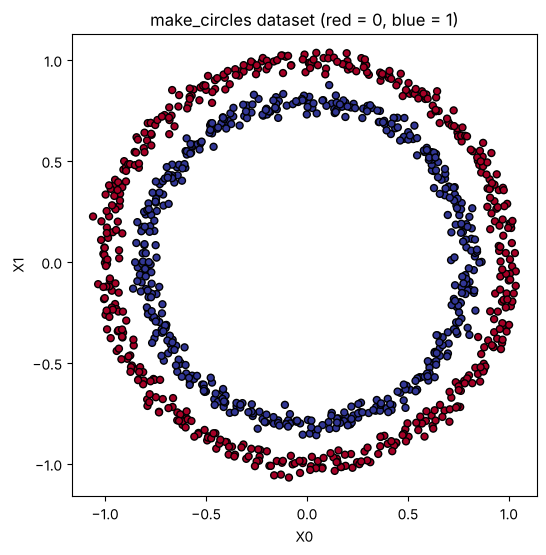

In [3]:
circles = pd.DataFrame({'X0': X[:, 0], 'X1': X[:, 1], 'label': y})
display(circles.head())
print(circles['label'].value_counts())

plt.figure(figsize=(6, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdYlBu, edgecolor='k', s=25)
plt.title('make_circles dataset (red = 0, blue = 1)')
plt.xlabel('X0')
plt.ylabel('X1')
plt.axis('equal')
plt.show()

The dataset contains 1,000 points with 2 features (their x and y coordinates) and a binary label, perfectly balanced (500 / 500). Label 1 points form the **inner circle** and label 0 points the **outer circle**. The two classes are **not linearly separable**: no straight line can separate them, so a linear model cannot solve this problem.

## 3. Build a Basic Neural Network Model

In [4]:
tf.keras.utils.set_random_seed(SEED)

# 1. Create the model: a single Dense layer with one neuron
model_1 = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(2,)),
    tf.keras.layers.Dense(1)
])

# 2. Compile it with binary cross-entropy and the SGD optimizer
model_1.compile(loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
                optimizer=tf.keras.optimizers.SGD(),
                metrics=['accuracy'])

# 3. Fit the model
model_1.fit(X, y, epochs=5, verbose=0)
loss_1, acc_1 = model_1.evaluate(X, y, verbose=0)
print(f"model_1 - 5 epochs: loss = {loss_1:.4f}, accuracy = {acc_1:.4f}")

# Training it longer does not help
model_1.fit(X, y, epochs=200, verbose=0)
loss_1b, acc_1b = model_1.evaluate(X, y, verbose=0)
print(f"model_1 - after 200 more epochs: loss = {loss_1b:.4f}, accuracy = {acc_1b:.4f}")

model_1 - 5 epochs: loss = 0.7388, accuracy = 0.4750


model_1 - after 200 more epochs: loss = 0.6932, accuracy = 0.5000


The basic model gets **about 50% accuracy**, i.e. no better than guessing at random on a balanced dataset, even after 200 more epochs. With a single neuron and no activation, the model computes w₁·X0 + w₂·X1 + b: it can only draw a **straight line**, which cannot separate two circles.

## 4. Improve the Model

We add more layers and neurons, train for more epochs, and compare SGD with Adam.

In [5]:
def build_model(hidden_units, activation=None, output_activation='sigmoid'):
    layers = [tf.keras.layers.Input(shape=(2,))]
    layers += [tf.keras.layers.Dense(u, activation=activation) for u in hidden_units]
    layers += [tf.keras.layers.Dense(1, activation=output_activation)]
    return tf.keras.Sequential(layers)

results = {}

# model_2: more layers and neurons, still SGD
tf.keras.utils.set_random_seed(SEED)
model_2 = build_model([100, 10])
model_2.compile(loss='binary_crossentropy', optimizer=tf.keras.optimizers.SGD(), metrics=['accuracy'])
model_2.fit(X, y, epochs=100, verbose=0)
results['model_2: 100-10, no hidden activation, SGD, 100 epochs'] = model_2.evaluate(X, y, verbose=0)

# model_3: same architecture, Adam optimizer
tf.keras.utils.set_random_seed(SEED)
model_3 = build_model([100, 10])
model_3.compile(loss='binary_crossentropy', optimizer=tf.keras.optimizers.Adam(), metrics=['accuracy'])
model_3.fit(X, y, epochs=100, verbose=0)
results['model_3: 100-10, no hidden activation, Adam, 100 epochs'] = model_3.evaluate(X, y, verbose=0)

display(pd.DataFrame(results, index=['loss', 'accuracy']).T.round(4))

,loss,accuracy
"model_2: 100-10, no hidden activation, SGD, 100 epochs",0.6932,0.483
"model_3: 100-10, no hidden activation, Adam, 100 epochs",0.6932,0.497


Adding layers (100 and 10 neurons), training for 100 epochs and switching from **SGD** to **Adam** does **not** improve the model: both versions stay at **~50% accuracy** (48.3% with SGD, 49.7% with Adam) and a loss of 0.693, which is exactly −ln(0.5), the loss of a model that always predicts 0.5. Adam usually converges faster than SGD because it adapts the learning rate of each weight, but no optimizer can fix a model that is fundamentally unable to represent the solution. The next section shows why.

## 5. Visualize the Decision Boundary

In [6]:
def plot_decision_boundary(model, X, y, ax=None, title=None):
    """Plot the decision boundary created by a model predicting on X."""
    if ax is None:
        _, ax = plt.subplots(figsize=(6, 6))
    # Create a grid covering the data
    x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
    y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
    grid = np.c_[xx.ravel(), yy.ravel()]

    # Predict on every grid point and turn probabilities into classes
    y_prob = model.predict(grid, verbose=0)
    if model.layers[-1].get_config().get('activation') == 'linear':
        y_prob = tf.sigmoid(y_prob).numpy()  # model_1 outputs logits
    y_pred = np.round(y_prob).reshape(xx.shape)

    ax.contourf(xx, yy, y_pred, cmap=plt.cm.RdYlBu, alpha=0.7)
    ax.scatter(X[:, 0], X[:, 1], c=y, s=25, cmap=plt.cm.RdYlBu, edgecolor='k')
    ax.set_xlim(xx.min(), xx.max())
    ax.set_ylim(yy.min(), yy.max())
    if title:
        ax.set_title(title)
    return ax

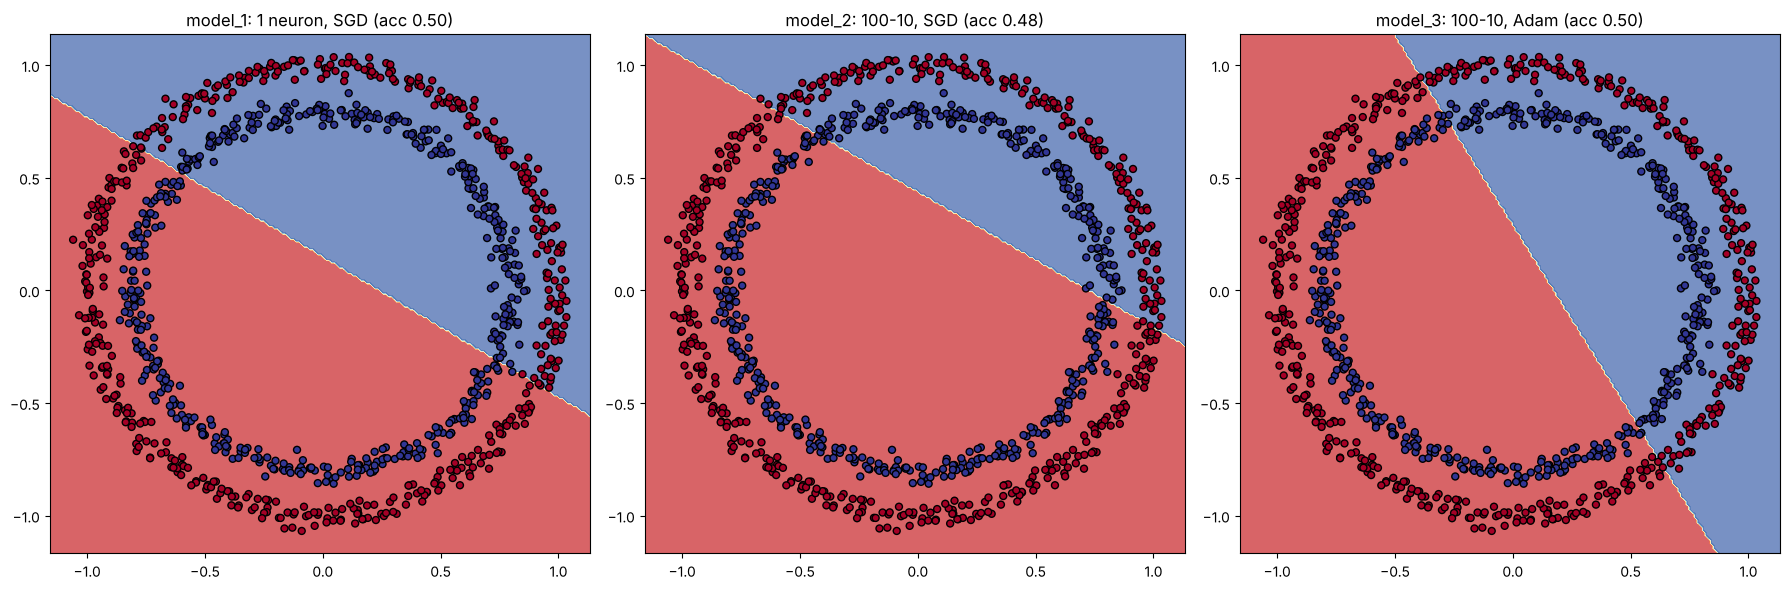

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
plot_decision_boundary(model_1, X, y, axes[0], f'model_1: 1 neuron, SGD (acc {acc_1b:.2f})')
plot_decision_boundary(model_2, X, y, axes[1], f'model_2: 100-10, SGD (acc {results[list(results)[0]][1]:.2f})')
plot_decision_boundary(model_3, X, y, axes[2], f'model_3: 100-10, Adam (acc {results[list(results)[1]][1]:.2f})')
plt.tight_layout()
plt.show()

All three decision boundaries are **straight lines**: the models split the plane in two halves and misclassify about half of the points. This is the key insight: adding layers does not help if they are all linear, because a stack of linear layers is still a single linear function. The model needs **non-linearity**.

## 6. Incorporate Activation Functions

We keep the same architecture and Adam optimizer, and only change the activation of the hidden layers.

,loss,accuracy
hidden activation = linear,0.6932,0.5
hidden activation = sigmoid,0.0093,1.0
hidden activation = relu,0.0004,1.0


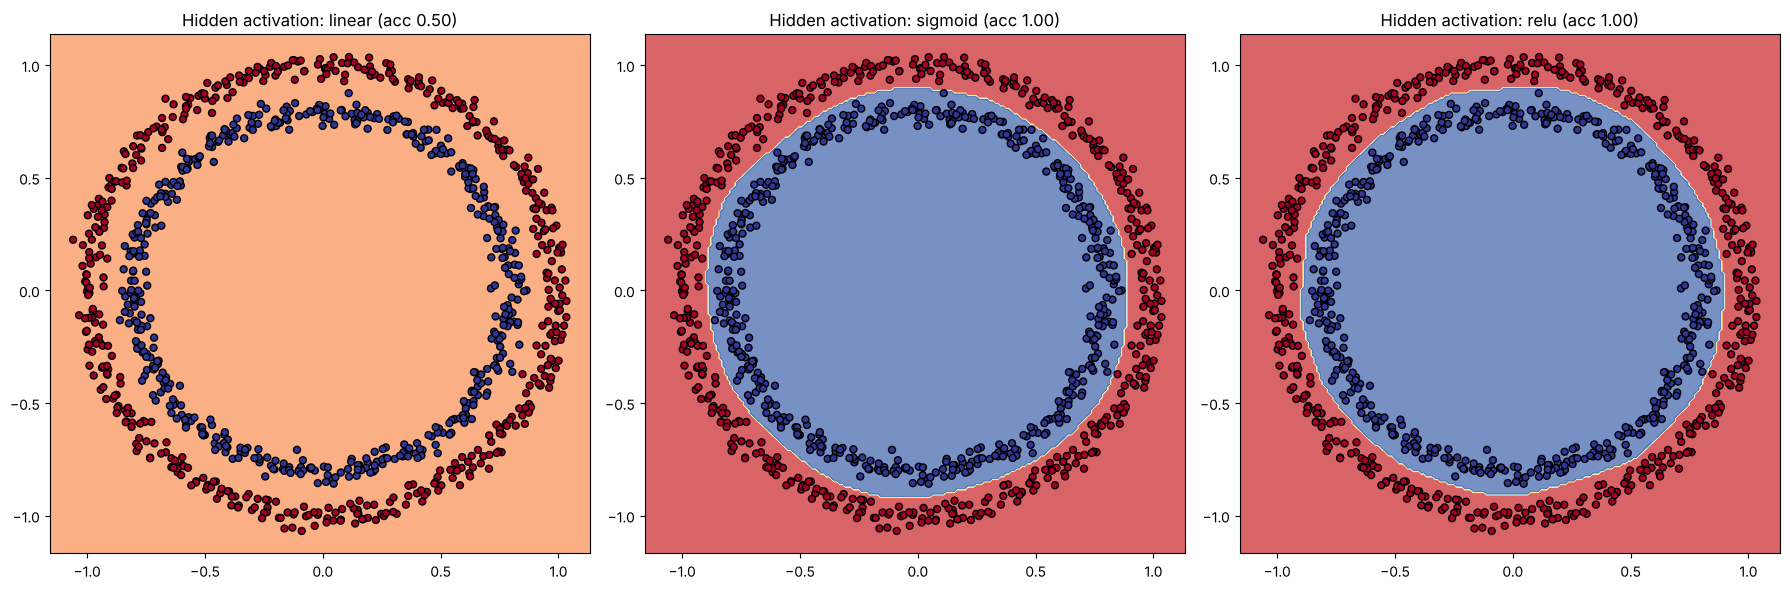

In [8]:
activation_results = {}
activation_models = {}
for act in ['linear', 'sigmoid', 'relu']:
    tf.keras.utils.set_random_seed(SEED)
    m = build_model([100, 10], activation=act)
    m.compile(loss='binary_crossentropy', optimizer=tf.keras.optimizers.Adam(learning_rate=0.01), metrics=['accuracy'])
    m.fit(X, y, epochs=100, verbose=0)
    activation_models[act] = m
    activation_results[f'hidden activation = {act}'] = m.evaluate(X, y, verbose=0)

display(pd.DataFrame(activation_results, index=['loss', 'accuracy']).T.round(4))

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, (act, m) in zip(axes, activation_models.items()):
    acc = activation_results[f'hidden activation = {act}'][1]
    plot_decision_boundary(m, X, y, ax, f'Hidden activation: {act} (acc {acc:.2f})')
plt.tight_layout()
plt.show()

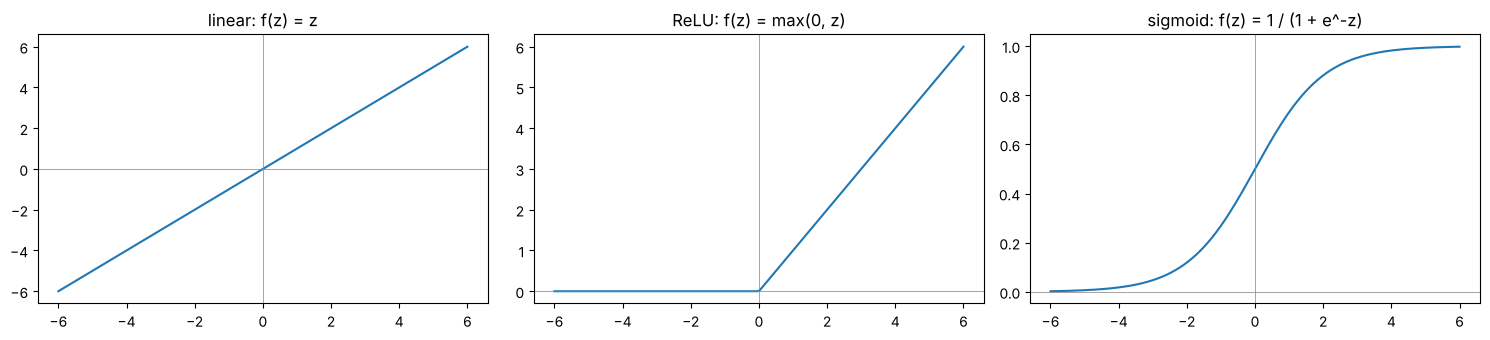

In [9]:
# What ReLU and sigmoid do to their input
z = np.linspace(-6, 6, 200)
fig, axes = plt.subplots(1, 3, figsize=(15, 3.5))
axes[0].plot(z, z); axes[0].set_title('linear: f(z) = z')
axes[1].plot(z, tf.nn.relu(z)); axes[1].set_title('ReLU: f(z) = max(0, z)')
axes[2].plot(z, tf.sigmoid(z)); axes[2].set_title('sigmoid: f(z) = 1 / (1 + e^-z)')
for ax in axes:
    ax.axhline(0, color='gray', lw=0.5); ax.axvline(0, color='gray', lw=0.5)
plt.tight_layout()
plt.show()

**Results:**

| Hidden activation | Loss | Accuracy |
|---|---|---|
| linear (none) | 0.693 | 0.50 |
| sigmoid | 0.009 | 1.00 |
| **ReLU** | **0.0004** | **1.00** |

Only the activation function changed, and it makes all the difference:
- **Linear**: the network is still equivalent to one straight line → 50%.
- **Sigmoid** in the hidden layers bends the space with an S-shaped curve: the model draws a closed, curved boundary around the inner circle and classifies all points correctly.
- **ReLU** (max(0, z)) is piecewise linear: combining many ReLU neurons builds a polygon that approximates the circle. It reaches the lowest loss and trains fastest, because it does not saturate (its gradient is 1 for positive inputs, while the sigmoid gradient becomes tiny for large |z|). This is why ReLU is the default choice for hidden layers.
- In every model the **output layer uses a sigmoid**, which turns the final value into a probability between 0 and 1 for the binary decision.

Note that these accuracies are measured on the data the models were trained on: we now check generalisation on a separate test set.

## 7. Split Data into Training and Testing Sets

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED, stratify=y)
print("Train:", X_train.shape, "| Test:", X_test.shape)

tf.keras.utils.set_random_seed(SEED)
final_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(2,)),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(8, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid'),
])
final_model.compile(loss='binary_crossentropy', optimizer=tf.keras.optimizers.Adam(learning_rate=0.01), metrics=['accuracy'])
final_model.summary()

history = final_model.fit(X_train, y_train, epochs=50, validation_split=0.1, verbose=0)

Train: (800, 2) | Test: (200, 2)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_16 (Dense)                │ (None, 16)             │            48 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 193 (772.00 B)

 Trainable params: 193 (772.00 B)

 Non-trainable params: 0 (0.00 B)

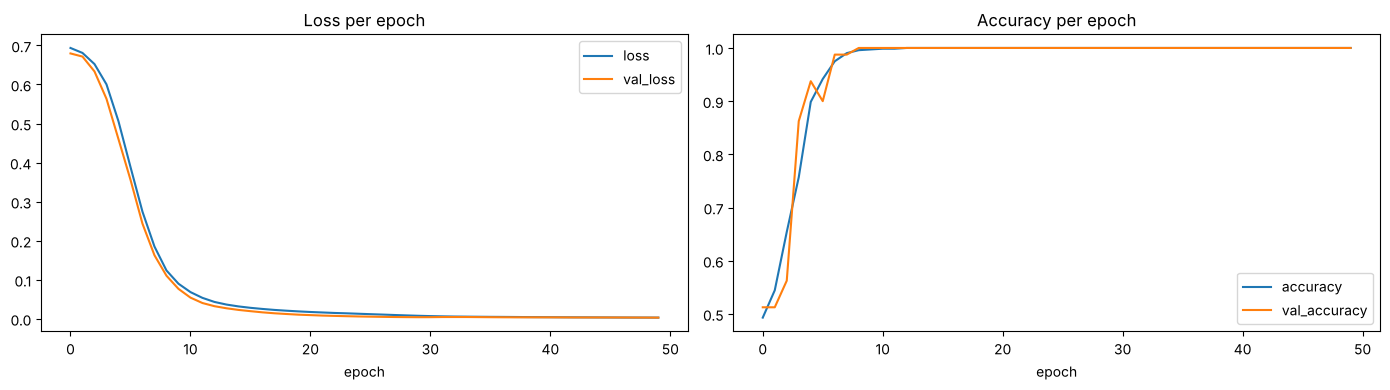

Final training accuracy: 1.0000 | validation accuracy: 1.0000


In [11]:
hist = pd.DataFrame(history.history)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
hist[['loss', 'val_loss']].plot(ax=axes[0], title='Loss per epoch')
hist[['accuracy', 'val_accuracy']].plot(ax=axes[1], title='Accuracy per epoch')
for ax in axes:
    ax.set_xlabel('epoch')
plt.tight_layout()
plt.show()
print(f"Final training accuracy: {hist['accuracy'].iloc[-1]:.4f} | validation accuracy: {hist['val_accuracy'].iloc[-1]:.4f}")

## 8. Evaluate and Visualize Final Model Performance

In [12]:
train_loss, train_acc = final_model.evaluate(X_train, y_train, verbose=0)
test_loss, test_acc = final_model.evaluate(X_test, y_test, verbose=0)
print(f"Train: loss = {train_loss:.4f}, accuracy = {train_acc:.4f}")
print(f"Test : loss = {test_loss:.4f}, accuracy = {test_acc:.4f}")

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
y_pred_test = (final_model.predict(X_test, verbose=0) > 0.5).astype(int).ravel()
print(f"Misclassified test points: {(y_pred_test != y_test).sum()} / {len(y_test)}")

Train: loss = 0.0056, accuracy = 1.0000
Test : loss = 0.0136, accuracy = 0.9950


Misclassified test points: 1 / 200


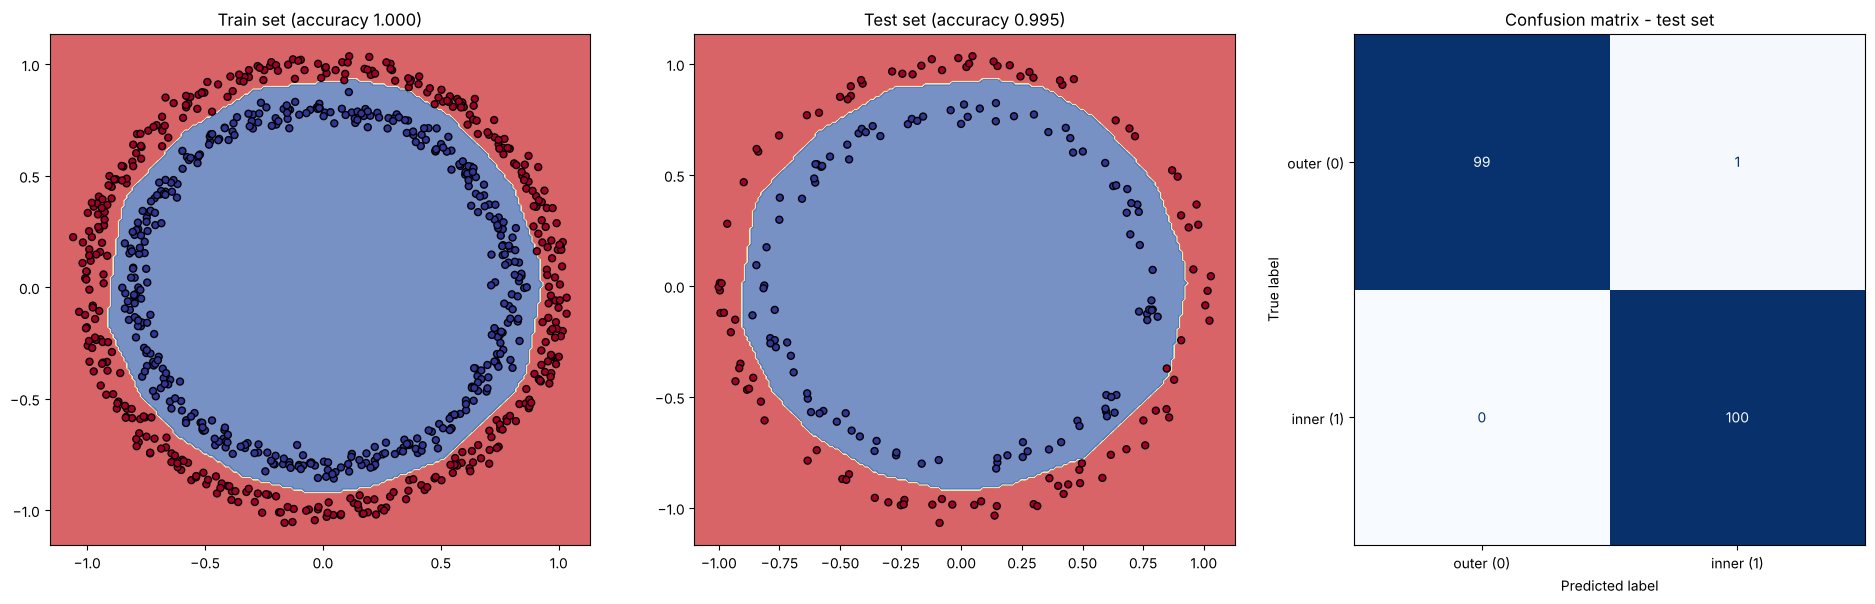

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(19, 6))
plot_decision_boundary(final_model, X_train, y_train, axes[0], f'Train set (accuracy {train_acc:.3f})')
plot_decision_boundary(final_model, X_test, y_test, axes[1], f'Test set (accuracy {test_acc:.3f})')
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_test), display_labels=['outer (0)', 'inner (1)']).plot(ax=axes[2], cmap='Blues', colorbar=False)
axes[2].set_title('Confusion matrix - test set')
plt.tight_layout()
plt.show()

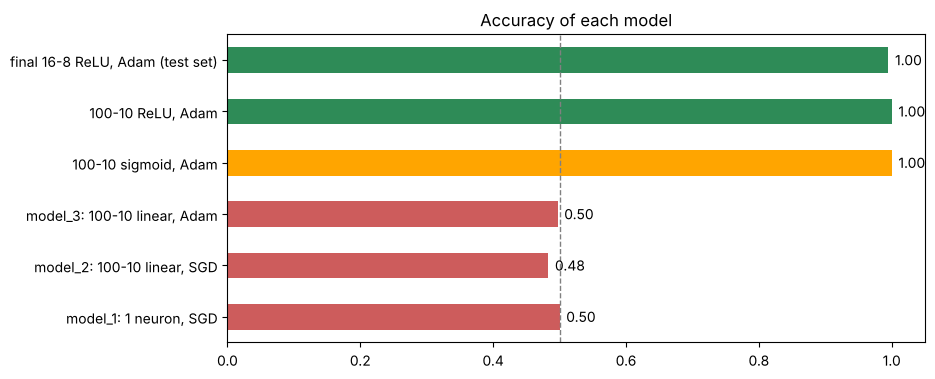

In [14]:
# Comparison of all the models trained in this notebook (accuracy on the full dataset)
summary = {
    'model_1: 1 neuron, SGD': acc_1b,
    'model_2: 100-10 linear, SGD': results[list(results)[0]][1],
    'model_3: 100-10 linear, Adam': results[list(results)[1]][1],
    '100-10 sigmoid, Adam': activation_results['hidden activation = sigmoid'][1],
    '100-10 ReLU, Adam': activation_results['hidden activation = relu'][1],
    'final 16-8 ReLU, Adam (test set)': test_acc,
}
s = pd.Series(summary)
s.plot(kind='barh', figsize=(9, 4), color=['indianred'] * 3 + ['orange', 'seagreen', 'seagreen'])
plt.xlim(0, 1.05)
plt.axvline(0.5, color='gray', ls='--', lw=1)
plt.title('Accuracy of each model')
for i, v in enumerate(s):
    plt.text(v + 0.01, i, f'{v:.2f}', va='center')
plt.show()

**Analysis of the final model:**
- A small network (2 → 16 → 8 → 1, only 193 parameters) with **ReLU** hidden layers, a **sigmoid** output and the **Adam** optimizer reaches **100% accuracy on the training set** and **99.5% on the test set** (1 misclassified point out of 200), with a test loss of 0.014.
- The training and validation curves go down together and the train and test scores are almost identical: the model **generalises** well and does not overfit.
- The decision boundary is a closed curve around the inner circle, on the training data as well as on the unseen test data. Only one test point ends up on the wrong side of the boundary.

## 9. Key Takeaways

- **Know your problem type:** binary (sigmoid + binary cross-entropy), multi-class (softmax + categorical cross-entropy) or multi-label (one sigmoid per label).
- **Visualise the data first:** the scatter plot immediately showed that the classes are not linearly separable, which explained why the first models were stuck at 50%.
- **Non-linearity is essential:** adding layers, neurons, epochs or changing the optimizer did nothing as long as the layers were linear. Adding a non-linear activation (ReLU or sigmoid) took the accuracy from 50% to ~100%.
- **Tune the hyperparameters:** the architecture, the activation, the optimizer (Adam vs SGD) and the learning rate all affect how fast and how well the model learns. Changing one thing at a time makes it possible to see what really helps.
- **Visualising decision boundaries** shows *how* the model separates the classes (a line vs a curve), which is much more informative than the accuracy number alone.
- **Always evaluate on a test set:** a model can be perfect on its training data; only the test set tells us whether it will work on new data.